<h1 style="color:pink;">
Hemoglobin Disorder Classification Using Machine Learning and Neural Networks 🩸🔎
</h1ٍ>



<h3 style="color:#89CFF0;">
- Task 1.1 
</h5>

<h3 style="color:PINK;">
 > Load and Explore
</h5>ٍ



<h3 style="color:#89CFF0;">
 > 1️⃣ Import Libraries
</h5>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-05-23 19:46:11.603623: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779565571.878633      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779565571.960363      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779565572.654701      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779565572.654760      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779565572.654783      57 computation_placer.cc:177] computation placer alr

<h3 style="color:#89CFF0;">
 > 2️⃣ Load Dataset
</h5>

In [2]:
df = pd.read_csv("/kaggle/input/datasets/dana3333/proj-data/hbvar_synthetic_clinical_dataset.csv")

<h3 style="color:#89CFF0;">
     3️⃣ Display First Rows <br>
     4️⃣ Check Shape  <br>
     5️⃣ Check Data Types <br>
     6️⃣ Check Missing Values
</h3>

In [3]:
df.head()
print("Rows and Columns:", df.shape)
df.info()
df.isnull().sum()


Rows and Columns: (3000, 34)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   variant_type      3000 non-null   object 
 1   ethnicity         3000 non-null   object 
 2   anemia            3000 non-null   int64  
 3   jaundice          3000 non-null   int64  
 4   splenomegaly      3000 non-null   int64  
 5   macrocytosis      3000 non-null   int64  
 6   microcytosis      3000 non-null   int64  
 7   hypochromia       3000 non-null   int64  
 8   poikilocytosis    3000 non-null   int64  
 9   hdeg_chronic      3000 non-null   int64  
 10  hdeg_mild         3000 non-null   int64  
 11  hdeg_moderate     3000 non-null   int64  
 12  hdeg_severe       3000 non-null   int64  
 13  hdeg_hemolytic    3000 non-null   int64  
 14  hdeg_congenital   3000 non-null   int64  
 15  hemoglobin        3000 non-null   float64
 16  rbc_count    

variant_type        0
ethnicity           0
anemia              0
jaundice            0
splenomegaly        0
macrocytosis        0
microcytosis        0
hypochromia         0
poikilocytosis      0
hdeg_chronic        0
hdeg_mild           0
hdeg_moderate       0
hdeg_severe         0
hdeg_hemolytic      0
hdeg_congenital     0
hemoglobin          0
rbc_count           0
pcv                 0
mcv                 0
mch                 0
mchc                0
hb_a                0
hb_a2               0
hb_f                0
hb_s                0
hb_h                0
hb_barts            0
hb_x                0
agamma              0
ggamma              0
alpha_beta_ratio    0
methemoglobin       0
reticulocytes       0
has_lab_data        0
dtype: int64

<h3 style="color:#89CFF0;">
 > Check Class Balance🔦
</h5>

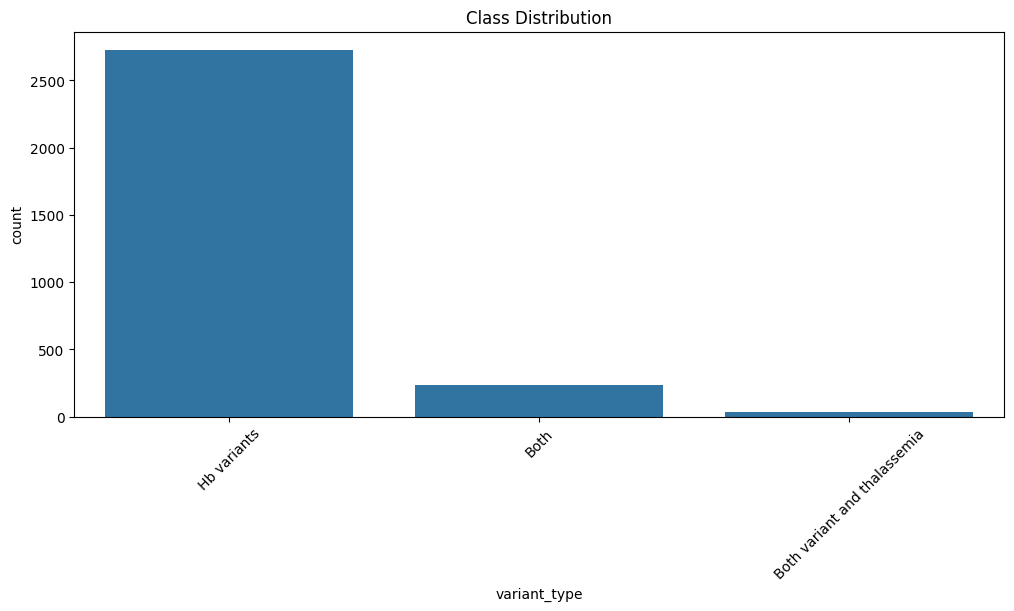

In [4]:
df["variant_type"].value_counts()

plt.figure(figsize=(12,5))
sns.countplot(x=df["variant_type"])
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()



The dataset is imbalanced because one class contains significantly more samples than the others.


Therefore, F1-score will be considered an important evaluation metric in this project.

<h3 style="color:PINK;">
 > Task 1.2
</h5>

 <h3 style="color:#89CFF0;">
 >  Features and Target
</h5>

In [5]:
X = df.drop("variant_type", axis=1)
y = df["variant_type"]

The dataset was separated into features (`X`) and target (`y`).

 <h3 style="color:#89CFF0;">
 >   Encoding Categorical Features
</h5>

In [6]:
X = pd.get_dummies(X, drop_first=True)

Categorical features were converted into numerical values using one-hot encoding.

 <h3 style="color:#89CFF0;">
 >   Encoding Target Labels
</h5>

In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

The target variable was converted into numerical labels using LabelEncoder.

 <h3 style="color:#89CFF0;">
 > Train-Test Split
</h5>

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

The dataset was split into 80% training data and 20% testing data.

 <h3 style="color:#89CFF0;">
 >Data Shapes
</h5>

In [9]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2400, 118)
X_test shape: (600, 118)
y_train shape: (2400,)
y_test shape: (600,)


The shapes of the training and testing datasets were checked successfully.

 <h3 style="color:#89CFF0;">
 >Feature Scaling
</h5>

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling was applied using StandardScaler to normalize the data before training the models.

<h3 style="color:PINK;">
 > Task 1.3
    " Logistic Regression "
</h3>

<h3 style="color:#89CFF0;">
Train the Model
</h3>

In [11]:

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

<h3 style="color:#89CFF0;">
Make Predictions
</h3>

In [12]:
y_pred_log = log_model.predict(X_test_scaled)

The trained Logistic Regression model was used to predict the test data.

<h3 style="color:#89CFF0;">
Model Evaluation
</h3>

In [13]:
log_accuracy = accuracy_score(y_test, y_pred_log)

log_precision = precision_score(y_test, y_pred_log, average="weighted")

log_recall = recall_score(y_test, y_pred_log, average="weighted")

log_f1 = f1_score(y_test, y_pred_log, average="weighted")

print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1-score:", log_f1)

Accuracy: 0.9366666666666666
Precision: 0.931680148297944
Recall: 0.9366666666666666
F1-score: 0.9340437158469946


The Logistic Regression model was evaluated using accuracy, precision, recall, and F1-score.

<h3 style="color:#89CFF0;">
Confusion Matrix
</h3>

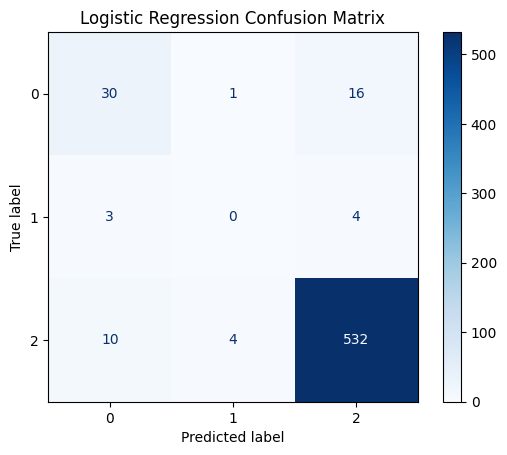

In [14]:
cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

### Logistic Regression Results

Logistic Regression achieved strong performance with high accuracy and F1-score.

However, the confusion matrix shows that the model performed better on the majority class than on the minority classes due to class imbalance.



<h3 style="color:PINK;">
 > Task 1.3
    " Random Forest "
</h3>

<h3 style="color:#89CFF0;">
Train the Model
</h3>
"

In [16]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

<h3 style="color:#89CFF0;">
Make Predictions
</h3>

In [17]:
y_pred_rf = rf_model.predict(X_test)

<h3 style="color:#89CFF0;">
Model Evaluation
</h3>

In [18]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(y_test, y_pred_rf, average="weighted")

rf_recall = recall_score(y_test, y_pred_rf, average="weighted")

rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)

Accuracy: 0.9533333333333334
Precision: 0.9432363636363638
Recall: 0.9533333333333334
F1-score: 0.9482173225976371


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<h3 style="color:#89CFF0;">
Confusion Matrix
</h3>

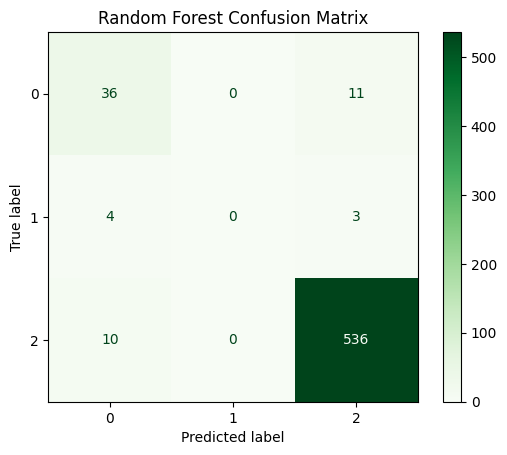

In [19]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)

disp.plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix")

plt.show()

### Random Forest Results

Random Forest achieved better performance than Logistic Regression in terms of accuracy and F1-score.

The model performed very well on the majority class, but the minority classes remained more difficult to classify because of class imbalance.

<h3 style="color:PINK;">
 > Task 1.3
    "K-Nearest Neighbors (KNN) "
</h3>

<h3 style="color:#89CFF0;">
Train the Model
</h3>

In [21]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

<h3 style="color:#89CFF0;">
Make Predictions
</h3>


In [22]:
y_pred_knn = knn_model.predict(X_test_scaled)

<h3 style="color:#89CFF0;">
Model Evaluation
</h3>


In [23]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

knn_precision = precision_score(y_test, y_pred_knn, average="weighted")

knn_recall = recall_score(y_test, y_pred_knn, average="weighted")

knn_f1 = f1_score(y_test, y_pred_knn, average="weighted")

print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1-score:", knn_f1)

Accuracy: 0.9366666666666666
Precision: 0.9204405797101448
Recall: 0.9366666666666666
F1-score: 0.9234828360921135


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<h3 style="color:#89CFF0;">
Confusion Matrix
</h3>

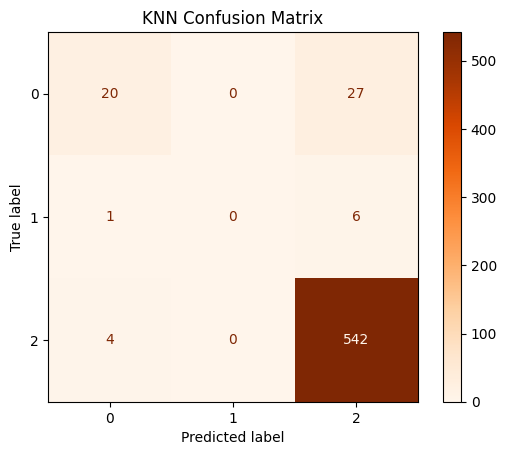

In [24]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)

disp.plot(cmap="Oranges")

plt.title("KNN Confusion Matrix")

plt.show()

### KNN Results

KNN achieved good performance, but its accuracy and F1-score were lower than Random Forest.

The confusion matrix shows that the model struggled more with minority classes due to class imbalance.

<h3 style="color:PINK;">
 > Summary Table
    "Model Comparison "
</h3>

In [26]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest","KNN"],
    
    "Accuracy": [log_accuracy,rf_accuracy,knn_accuracy],
    "Precision": [log_precision,rf_precision,knn_precision],
    "Recall": [log_recall,rf_recall,knn_recall],
    "F1-Score": [log_f1,rf_f1,knn_f1]})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.936667,0.931680,0.936667,0.934044
1,Random Forest,0.953333,0.943236,0.953333,0.948217
2,KNN,0.936667,0.920441,0.936667,0.923483


### Best Model Selection

Random Forest achieved the best overall performance among all models.

It produced the highest accuracy and F1-score, making it the most effective model for classifying hemoglobin disorder types in this dataset.🚀

<h3 style="color:PINK;">
 > Step 1 complated 🎉
</h3>

<h3 style="color:PINK;">
🚀 Step 2 — Neural Network
</h3>

<h3 style="color:#89CFF0;">
Build the Neural Network
</h3>

In [28]:
nn_model = keras.Sequential([
    
    layers.Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    
    layers.Dropout(0.3),
    
    layers.Dense(64, activation="relu"),
    
    layers.Dropout(0.3),
    
    layers.Dense(3, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-23 19:48:07.123436: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


A neural network model was created using Dense and Dropout layers.

<h3 style="color:#89CFF0;">
Compile the Model
</h3>

In [29]:
nn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

The model was compiled using the Adam optimizer and categorical loss function.

<h3 style="color:#89CFF0;">
Train the Mode
</h3>

In [30]:
history = nn_model.fit(
    X_train_scaled,
    y_train,
    
    validation_split=0.2,
    
    epochs=15,
    
    batch_size=32
)

Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8571 - loss: 0.6006 - val_accuracy: 0.9375 - val_loss: 0.1872
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9285 - loss: 0.2462 - val_accuracy: 0.9458 - val_loss: 0.1463
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9506 - loss: 0.1721 - val_accuracy: 0.9479 - val_loss: 0.1415
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9474 - loss: 0.1562 - val_accuracy: 0.9438 - val_loss: 0.1444
Epoch 5/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9480 - loss: 0.1442 - val_accuracy: 0.9458 - val_loss: 0.1432
Epoch 6/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9685 - loss: 0.1002 - val_accuracy: 0.9438 - val_loss: 0.1470
Epoch 7/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9555 - loss: 0.1142 - val_accuracy: 0.9417 - val_loss: 0.1475
Epoch 8/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9589 - loss: 0.1057 - val_accuracy: 0.9375 - val_loss:

The neural network was trained using the training dataset and validation split.

<h3 style="color:#89CFF0;">
Training and Validation Curves
</h3>

The training and validation accuracy/loss curves were plotted to check model performance and overfitting.

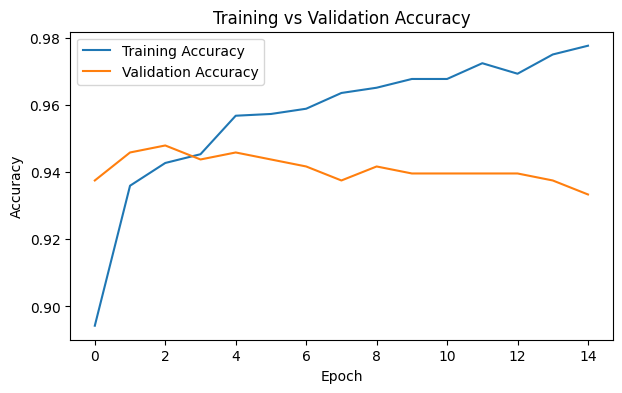

In [31]:
plt.figure(figsize=(7,4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### Accuracy Curve Analysis

The model achieved high accuracy with slight overfitting in later epochs.

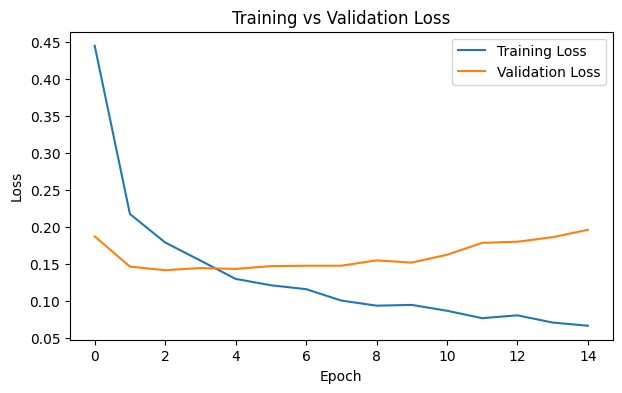

In [32]:
plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

### Loss Curve Analysis

The loss decreased during training with slight overfitting in later epochs.

<h3 style="color:PINK;">
Evaluate the Neural Network
</h3>

The neural network model was evaluated using the same metrics from Step 1.

<h3 style="color:#89CFF0;">
Evaluate on Test Set
</h3>

In [33]:
test_loss, test_accuracy = nn_model.evaluate(X_test_scaled, y_test)

print("Test Accuracy:", test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9506 - loss: 0.1966  
Test Accuracy: 0.9416666626930237


<h3 style="color:#89CFF0;">
Predictions
</h3>

In [34]:
y_pred_nn = nn_model.predict(X_test_scaled)

y_pred_nn = y_pred_nn.argmax(axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


<h3 style="color:#89CFF0;">
Metrics
</h3>

### Add Neural Network to Summary Table

In [35]:
nn_precision = precision_score(y_test, y_pred_nn, average="weighted")

nn_recall = recall_score(y_test, y_pred_nn, average="weighted")

nn_f1 = f1_score(y_test, y_pred_nn, average="weighted")

print("Precision:", nn_precision)
print("Recall:", nn_recall)
print("F1-score:", nn_f1)

Precision: 0.9346000328130128
Recall: 0.9416666666666667
F1-score: 0.9379950157260313


<h3 style="color:#89CFF0;">
Add to Summary Table
</h3>

In [36]:
results.loc[len(results)] = [
    "Neural Network",
    test_accuracy,
    nn_precision,
    nn_recall,
    nn_f1
]

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.936667,0.931680,0.936667,0.934044
1,Random Forest,0.953333,0.943236,0.953333,0.948217
2,KNN,0.936667,0.920441,0.936667,0.923483
3,Neural Network,0.941667,0.934600,0.941667,0.937995


<h3 style="color:#89CFF0;">
Final Comparison
</h3>

### Final Comparison

Random Forest achieved the best overall performance among all models.

Although the Neural Network achieved strong results, Random Forest produced higher accuracy and F1-score on this dataset.